# Stage 5 — Calibration Evaluation

Evaluate cone detection and homography / single-axis calibration on the first frame.

**What this notebook covers:**
- HSV cone detection with current defaults (yellow, orange, blue, red)
- Visualising detected cone centroids overlaid on the first frame
- Running `Calibrator.calibrate_homography` or `calibrate_single_axis`
- Reprojection error check
- World-coordinate mapping: pixel → real-world cm

In [ ]:
import os
# Avoid RTX 5080 (sm_120) CUDA incompatibility with current PyTorch — use CPU for this notebook
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")

import sys
sys.path.insert(0, '..')

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

VIDEO_PATH  = Path('../data/raw_footage/shuttles_test_behind.mp4')

# Cone world coordinates in cm — adapt to your test setup.
# For explosiveness: no cones needed (single-axis).
# For sprint:        [(0, 0), (500, 0)]   (5 m start/finish)
CONE_WORLD_COORDS_CM = []

# Or use cone_layout (spacing + first cone) — see template cell below
CONE_LAYOUT = {}

from pipeline.ingest import extract_frames
frames_iter = extract_frames(str(VIDEO_PATH), target_fps=15)
_, first_frame, _ = next(frames_iter)
print(f"First frame shape: {first_frame.shape}")

## Cone layout templates (spacing + first cone)

Instead of listing every world coord, specify **spacing** and **first cone**; coords are generated automatically. Order matches detected cones (sorted top→bottom, left→right).

**Linear** (sprint, shuttle). Add `cone_count` so filtering selects the target cones when SAM over-detects:
```python
CONE_LAYOUT = {
    "pattern": "linear",
    "first_cone_cm": [0, 0],
    "spacing_cm": 200,
    "direction": "x",
    "cone_count": 6,   # required for confidence + grid filtering
}
```

**Grid** (e.g. agility T-drill):
```python
CONE_LAYOUT = {
    "pattern": "grid",
    "first_cone_cm": [0, 0],
    "spacing_cm": 150,
    "rows": 2,
    "cols": 4,
}
```

**Clustered** (cones around each person — e.g. gym layout):
```python
CONE_LAYOUT = {
    "pattern": "clustered",
    "cluster_radius_px": 150,   # group cones within 150 px
    "clusters": [
        {"origin_cm": [0, 0], "spacing_cm": 50, "direction": "x"},
        {"origin_cm": [250, 0], "spacing_cm": 50, "direction": "x"},
        {"origin_cm": [500, 0], "spacing_cm": 50, "direction": "x"},
        # ... one per person/cluster
    ],
}
```

In [ ]:
# ── Choose layout: explicit coords OR spacing-based layout ───────────────────
# Optional: load from test config (same keys as worker: calibration_detector, calibration_model, calibration_prompt, calibration_min_confidence)
import json
geometry_config = {}
TEST_TYPE = "fitness"  # e.g. "fitness" to load configs/test_configs/fitness.json and use its SAM3 + layout

if TEST_TYPE:
    config_file = Path("../configs/test_configs") / f"{TEST_TYPE}.json"
    if config_file.exists():
        with open(config_file) as f:
            geometry_config = json.load(f)
        CONE_LAYOUT = dict(geometry_config.get("cone_layout", {}))
        if "cone_count" not in CONE_LAYOUT and "cone_count" in geometry_config:
            CONE_LAYOUT["cone_count"] = geometry_config["cone_count"]
        CONE_WORLD_COORDS_CM = geometry_config.get("cone_world_coords_cm", [])
    else:
        CONE_WORLD_COORDS_CM = []
        CONE_LAYOUT = {}
else:
    # Option A: Explicit world coords (original)
    CONE_WORLD_COORDS_CM = []  # e.g. [(0, 0), (500, 0)] for 5 m sprint
    # Option B: Layout from spacing + first cone (cone_count required when using SAM3)
    CONE_LAYOUT = {
        "pattern": "linear",
        "first_cone_cm": [0, 0],
        "spacing_cm": 200,
        "direction": "x",
        "cone_count": 6,
    }
# Set CONE_LAYOUT = {} to use single-axis calibration instead

print(CONE_LAYOUT)
print(CONE_WORLD_COORDS_CM)

{'pattern': 'grid', 'first_cone_cm': [0, 0], 'spacing_cm': 400, 'spacing_cm_x': 70, 'spacing_cm_y': 300, 'rows': 6, 'cols': 7, 'grid_fit_use_iterative': True, 'grid_fit_max_iters': 20, 'grid_fit_match_radius_px': 50, 'grid_fit_min_inliers': 4, 'grid_fit_use_confidence_weights': False, 'cone_count': 42}
[]


HSV value ranges in first frame:
  H: 0–179
  S: 0–255
  V: 0–255


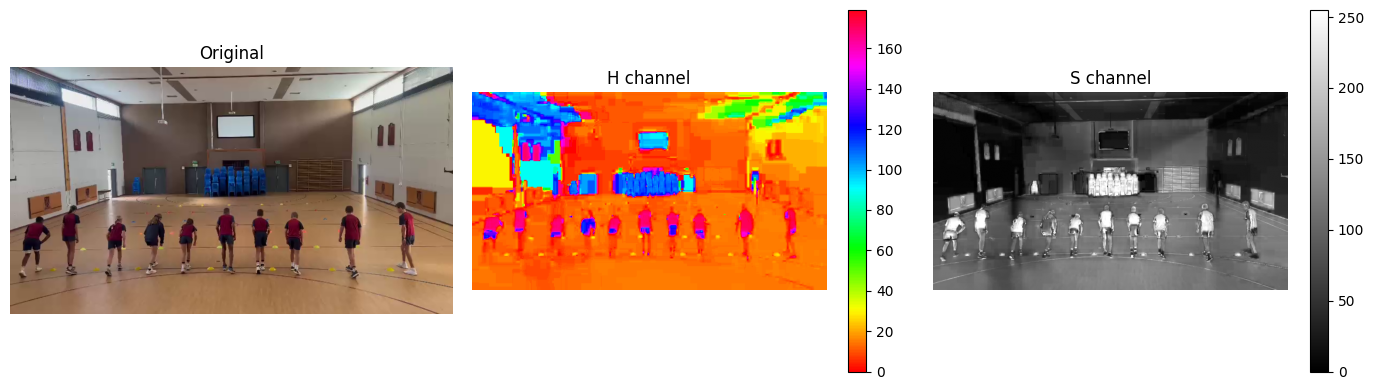

In [ ]:
# ── Inspect HSV range of the first frame ─────────────────────────────────────
hsv = cv2.cvtColor(first_frame, cv2.COLOR_BGR2HSV)
print(f"HSV value ranges in first frame:")
print(f"  H: {hsv[:,:,0].min()}–{hsv[:,:,0].max()}")
print(f"  S: {hsv[:,:,1].min()}–{hsv[:,:,1].max()}")
print(f"  V: {hsv[:,:,2].min()}–{hsv[:,:,2].max()}")

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1); plt.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)); plt.title('Original'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(hsv[:,:,0], cmap='hsv'); plt.title('H channel'); plt.colorbar(); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(hsv[:,:,1], cmap='gray'); plt.title('S channel'); plt.colorbar(); plt.axis('off')
plt.tight_layout(); plt.show()

Using SAM3/layout from config (geometry_config). Re-run the layout cell after editing the JSON to apply changes.


/home/alex/PycharmProjects/vigour-poc/.venv/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (1.26.20) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(



Ultralytics 8.4.19 🚀 Python-3.11.12 torch-2.4.0+cu121 CPU (Intel Core i9-9820X 3.30GHz)
0: 1036x1036 39 training cones, 20069.8ms
Speed: 10.1ms preprocess, 20069.8ms inference, 31.2ms postprocess per image at shape (1, 3, 1036, 1036)
Results saved to /home/alex/PycharmProjects/vidoe-detector/runs/segment/predict52
Detected 36 cone(s) with prompt='training cone'


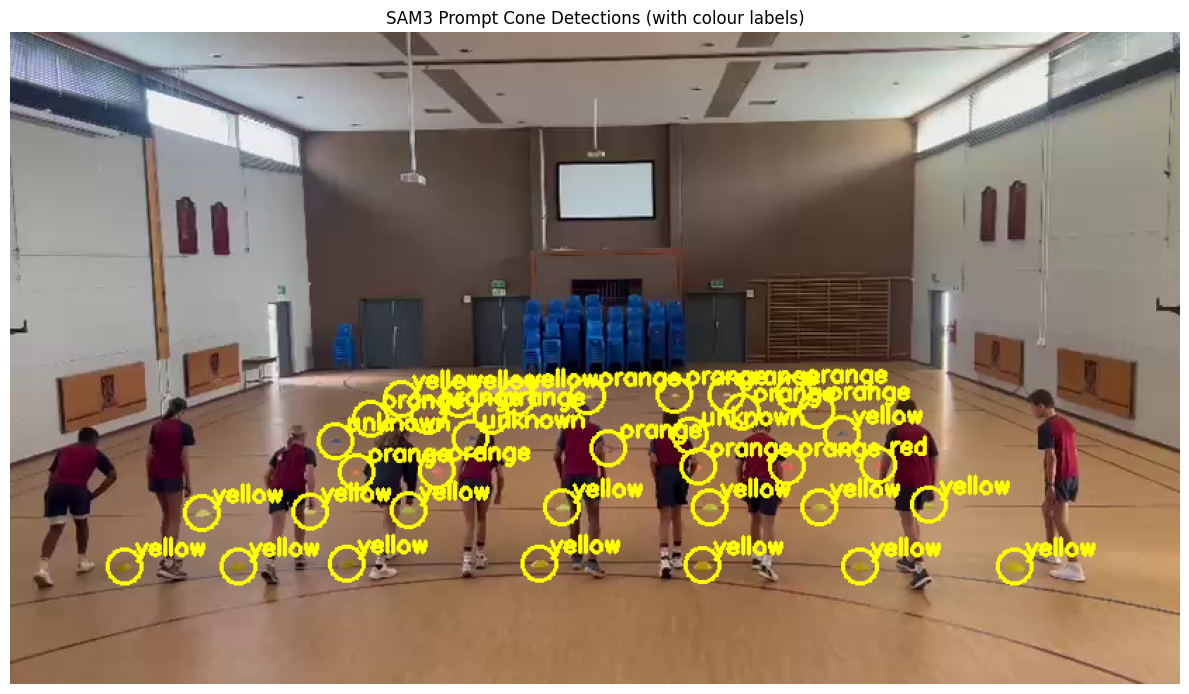

In [ ]:
from pipeline.calibrate import Calibrator

# SAM3 config: use geometry_config from layout cell (run that cell first with TEST_TYPE set to load from JSON).
try:
    _cfg = geometry_config
except NameError:
    _cfg = {}
if _cfg:
    print("Using SAM3/layout from config (geometry_config). Re-run the layout cell after editing the JSON to apply changes.")
else:
    print("Using notebook defaults for SAM3. Set TEST_TYPE in the layout cell (e.g. 'fitness') to load from config.")
calibrator = Calibrator(
    detector_backend=_cfg.get("calibration_detector", "sam3_prompt"),
    sam_model_path=_cfg.get("calibration_model", "sam3.pt"),
    sam_prompt=_cfg.get("calibration_prompt", "training cone"),
    min_confidence=0.4,
)

canvas = first_frame.copy()
cones = calibrator.detect_cones(first_frame)
print(f"Detected {len(cones)} cone(s) with prompt='{calibrator.sam_prompt}'")

for cone in calibrator.last_detected_cones:
    cx, cy = int(cone.cx), int(cone.cy)
    label = cone.colour_label
    cv2.circle(canvas, (cx, cy), 12, (0, 255, 255), 2)
    cv2.putText(
        canvas,
        label,
        (cx + 8, cy - 8),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (0, 255, 255),
        2,
    )

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title('SAM3 Prompt Cone Detections (with colour labels)'); plt.axis('off')
plt.tight_layout(); plt.show()

### Grid iterative fitting (fitness)

For **pattern: grid** (e.g. fitness 6×7), calibration can use an iterative fitter that assigns detections to grid positions and refits homography until stable. This works with **partial cone detections** (you don't need all 42 cones). Set `TEST_TYPE = "fitness"` in the layout cell and run the layout + calibration cells to use it. Optional: run `python scripts/run_grid_calibration.py [video_path]` to validate from the command line.

In [ ]:
# ── Run calibration ───────────────────────────────────────────────────────────
from pipeline.cache import PipelineCache

JOB_ID = 'notebook-eval-detection'
cache  = PipelineCache(job_id=JOB_ID, cache_root=Path('../data/cache'))

if CONE_WORLD_COORDS_CM:
    calibration = calibrator.calibrate_homography(first_frame, CONE_WORLD_COORDS_CM)
elif CONE_LAYOUT and CONE_LAYOUT.get("pattern"):
    calibration = calibrator.calibrate_from_layout(first_frame, CONE_LAYOUT)
else:
    calibration = calibrator.calibrate_single_axis(first_frame)

cache.save_calibration(calibration)

print(f"Calibration method : {calibration.method}")
print(f"Valid              : {calibration.is_valid}")
print(f"Reprojection error : {calibration.reprojection_error_px:.3f} px")
print(f"Pixels per cm      : {calibration.pixels_per_cm}")
if calibration.homography_matrix is not None:
    print(f"Homography H:\n{calibration.homography_matrix.round(4)}")


0: 1036x1036 39 training cones, 21398.8ms
Speed: 6.8ms preprocess, 21398.8ms inference, 39.8ms postprocess per image at shape (1, 3, 1036, 1036)
Results saved to /home/alex/PycharmProjects/vidoe-detector/runs/segment/predict52
Calibration method : homography
Valid              : True
Reprojection error : 0.072 px
Pixels per cm      : None
Homography H:
[[    -4.7194     -7.1514      5052.9]
 [    -1.7888      7.7122     -1519.6]
 [     0.0018     -0.0022           1]]


In [ ]:
# ── Test world coordinate mapping ─────────────────────────────────────────────
if calibration.is_valid:
    # Test a few pixel positions
    test_pixels = [
        (first_frame.shape[1]//2, first_frame.shape[0]//2),  # centre
        (100, 100),
        (500, 400),
    ]
    print("Pixel → World (cm) mapping:")
    for px, py in test_pixels:
        world = calibrator.pixel_to_world((float(px), float(py)), calibration)
        print(f"  pixel ({px:4d}, {py:4d})  →  world ({world[0]:.1f} cm, {world[1]:.1f} cm)")
else:
    print("Calibration not valid — cannot map pixels to world coordinates.")

Pixel → World (cm) mapping:
  pixel ( 416,  232)  →  world (1145.8 cm, -380.1 cm)
  pixel ( 100,  100)  →  world (4015.1 cm, -963.1 cm)
  pixel ( 500,  400)  →  world (-162.0 cm, 649.3 cm)


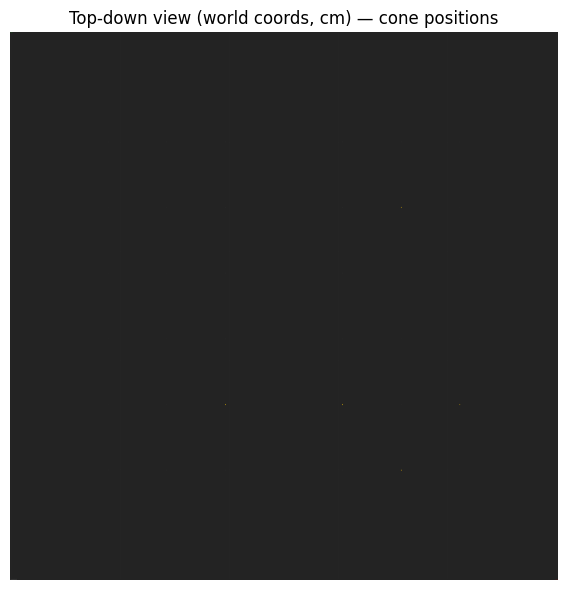

In [ ]:
# ── Top-down world-coords view ─────────────────────────────────────────────────
# Shows cone positions in world coordinates (cm). Person positions appear when
# running the full pipeline (e.g. poc_validation notebook).
# If CONE_LAYOUT has pattern + cone_count, full expected grid is drawn (open circles);
# filled circles = cones actually used for calibration.
if calibration.is_valid:
    from pipeline.visualise import render_top_down_view
    from pipeline.cone_layout import generate_cone_world_coords

    expected_grid = None
    try:
        layout = globals().get("CONE_LAYOUT") or {}
        cfg = globals().get("geometry_config") or {}
        n = layout.get("cone_count") or cfg.get("cone_count", 0)
        if not n and layout.get("pattern") == "grid":
            rows = int(layout.get("rows", 0) or 0)
            cols = int(layout.get("cols", 0) or 0)
            n = rows * cols
        if layout.get("pattern") and n >= 4:
            expected_grid = generate_cone_world_coords(layout, int(n))
    except Exception:
        pass
    top_down = render_top_down_view(
        calibration, tracks=[], poses=[], size=(10000, 10000),
        expected_cone_positions_world=expected_grid,
    )
    plt.figure(figsize=(6, 6))
    plt.imshow(top_down[:, :, ::-1])  # BGR → RGB
    plt.title('Top-down view (world coords, cm) — cone positions')
    plt.axis('off')
    plt.tight_layout()
    plt.show()